In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### Import dataset

In [2]:
df = pd.read_csv("data\loan.csv")

In [3]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.shape

(4269, 13)

#### Dataset Information 
- loan id 
- no_of_dependents -> Number of Dependents of the Applicant
- education -> Education of the Applicant
- self_employed -> Employment Status of the Applicant
- income_annum	-> Annual Income of the Applicant
- loan_amount	-> Loan Amount
- loan_term	   -> Loan Term in Years
- cibil_score	-> Credit Score
- residential_assets_value	-> 
- commercial_assets_value	
- luxury_assets_value	
- bank_asset_value	
- loan_status -> target feature

#### Check Missing values 


In [6]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

There are no missing values

#### Check Duplicates 

In [7]:
df.duplicated().sum()

0

#### Check data types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


#### Checking the number of unique values of each column

In [9]:
df.nunique()

loan_id                      4269
 no_of_dependents               6
 education                      2
 self_employed                  2
 income_annum                  98
 loan_amount                  378
 loan_term                     10
 cibil_score                  601
 residential_assets_value     278
 commercial_assets_value      188
 luxury_assets_value          379
 bank_asset_value             146
 loan_status                    2
dtype: int64

#### Check Statistics of data set 

In [10]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [11]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"'{col}' = {outliers_count} outliers.")

'loan_id' = 0 outliers.
' no_of_dependents' = 0 outliers.
' income_annum' = 0 outliers.
' loan_amount' = 0 outliers.
' loan_term' = 0 outliers.
' cibil_score' = 0 outliers.
' residential_assets_value' = 52 outliers.
' commercial_assets_value' = 37 outliers.
' luxury_assets_value' = 0 outliers.
' bank_asset_value' = 5 outliers.


#### Insights
- income_annum and cibil_score normally distributed
- loan_amount, luxury_assets_value, bank_asset_value have outlier(close to max value)
- residential_assets_value min value is in negative assets value never can be negative 

In [14]:
## Remove spaces 
df.columns = df.columns.str.strip()

#### Exploring the data 

In [15]:
def explore_data(feature):
    print(f"--- Analysis for {feature} ---")
    print("Unique Categories:", df[feature].unique())
    print("\nCounts of each category:")
    print(df[feature].value_counts())
    print("-" * 30 + "\n")


for col in ["education", "self_employed"]:
    explore_data(col)

--- Analysis for education ---
Unique Categories: [' Graduate' ' Not Graduate']

Counts of each category:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
------------------------------

--- Analysis for self_employed ---
Unique Categories: [' No' ' Yes']

Counts of each category:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
------------------------------



In [16]:
cat_features = [feature for feature in df.columns if df.columns.dtype == "O"]
num_features = [feature for feature in df.columns if df.columns.dtype != "O"]

In [17]:
cat_features

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [19]:
print(f"We have {len(cat_features)} categorical features : {cat_features}")
print(f"We have {len(num_features)} numerical features : {num_features}")

We have 13 categorical features : ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']
We have 0 numerical features : []


In [20]:
## loan id is not important so we drop it 
df.drop(columns=["loan_id"], inplace=True)

In [21]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


#### Exploring Data ( Visualization )

##### Histograms and KDE

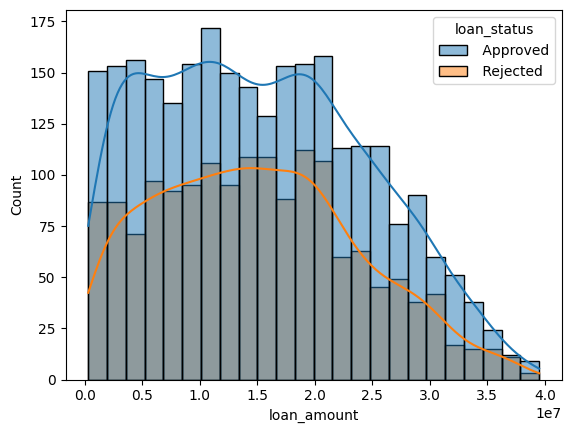

In [29]:
sns.histplot(x="loan_amount", data=df,kde= True, hue="loan_status")
plt.show()

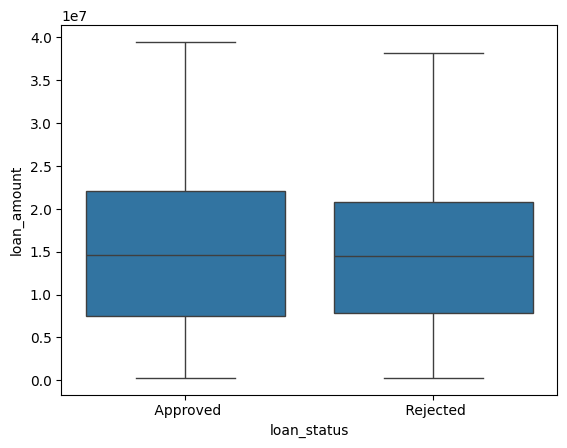

In [35]:
sns.boxplot(x='loan_status', y='loan_amount', data=df)
plt.show()

### Insight

- loan amount does not appear to be a strong factor in distinguishing approved and rejected loans.

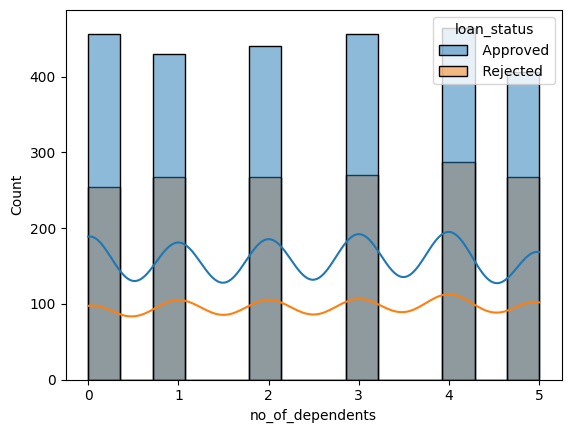

In [42]:
sns.histplot(x='no_of_dependents', data=df, kde=True,hue='loan_status')
plt.show()

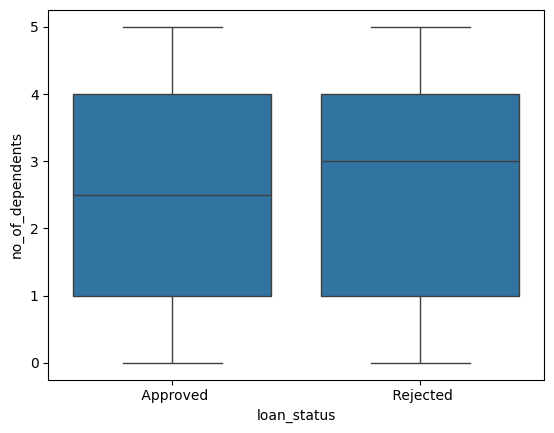

In [43]:
sns.boxplot(x='loan_status', y='no_of_dependents', data=df)
plt.show()

### Insight

- median of no of dependent and loan status both are same 

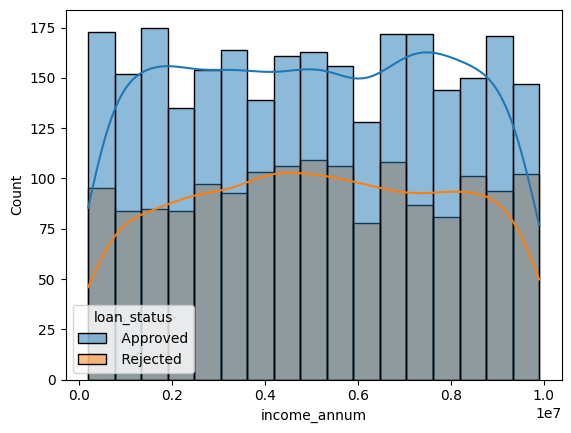

In [44]:
sns.histplot(x="income_annum", data=df,kde= True, hue="loan_status")
plt.show()

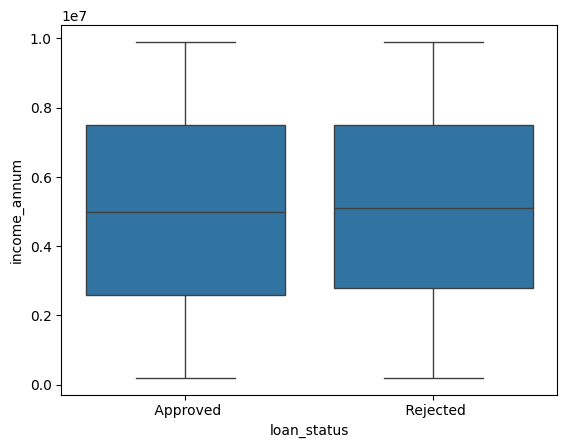

In [45]:
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.show()

### Insight 

- income_annum is not strong differentiating feature for loan approval

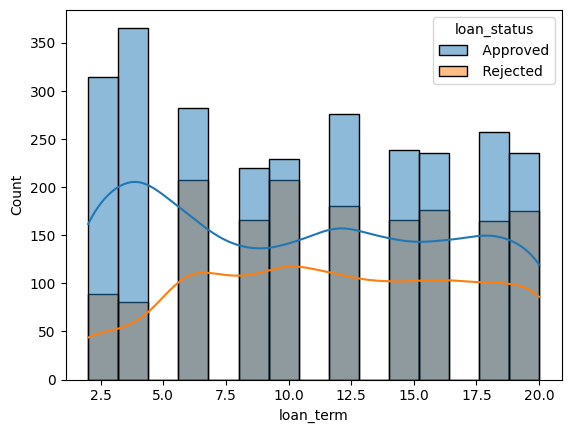

In [46]:
sns.histplot(x="loan_term", data=df,kde= True, hue="loan_status")
plt.show()

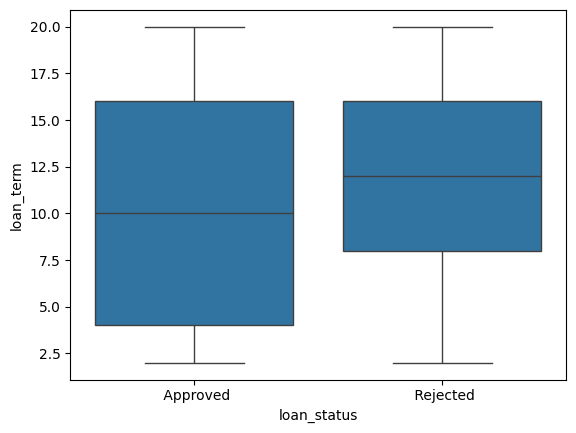

In [47]:
sns.boxplot(x='loan_status', y='loan_term', data=df)
plt.show()

### Insight

- loan_term is not strong differentiating feature for loan approval

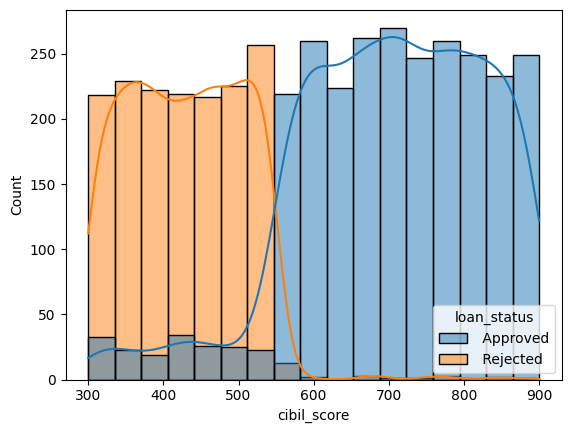

In [48]:
sns.histplot(x="cibil_score", data=df,kde= True, hue="loan_status")
plt.show()

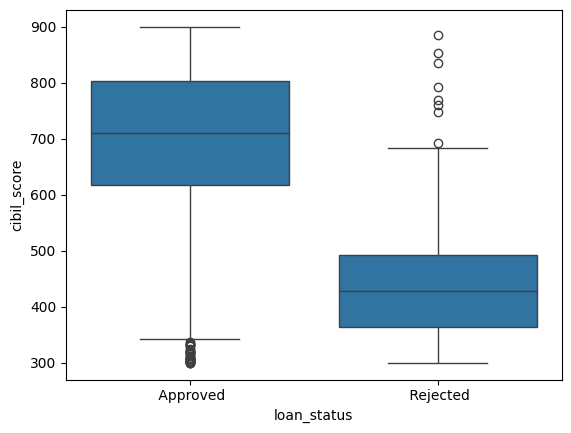

In [49]:
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.show()

### Insight

- cibil_score is strong differentiating feature for loan approval

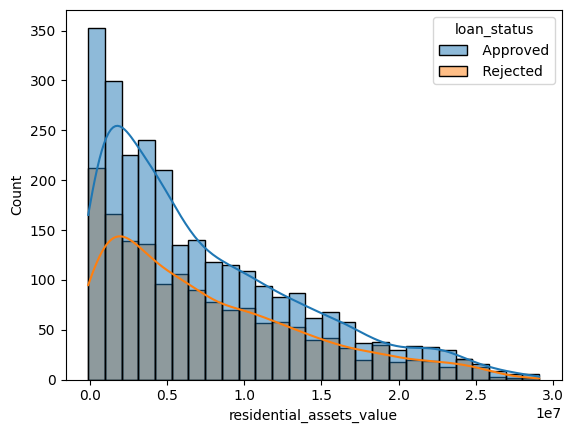

In [53]:
sns.histplot(x="residential_assets_value", data=df,kde= True, hue="loan_status")
plt.show()

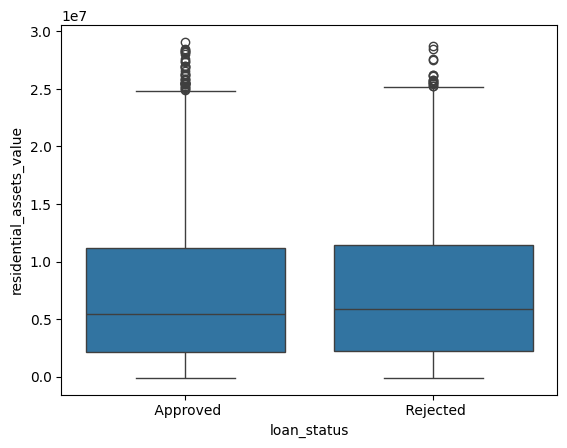

In [54]:
sns.boxplot(x='loan_status', y='residential_assets_value', data=df)
plt.show()

### Insight
- residential_assets_value is not strong differentiating feature for loan approval

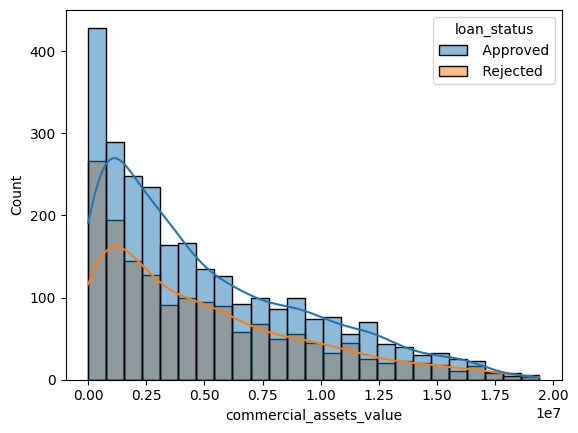

In [55]:
sns.histplot(x="commercial_assets_value", data=df,kde= True, hue="loan_status")
plt.show()

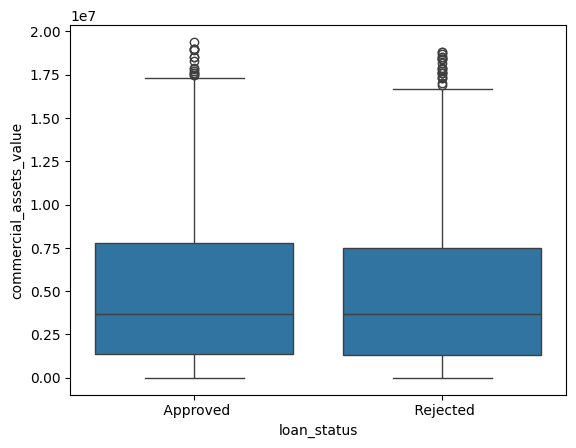

In [56]:
sns.boxplot(x='loan_status', y='commercial_assets_value', data=df)
plt.show()

### Insight

- commercial_assets_value is not strong differentiating feature for loan approval

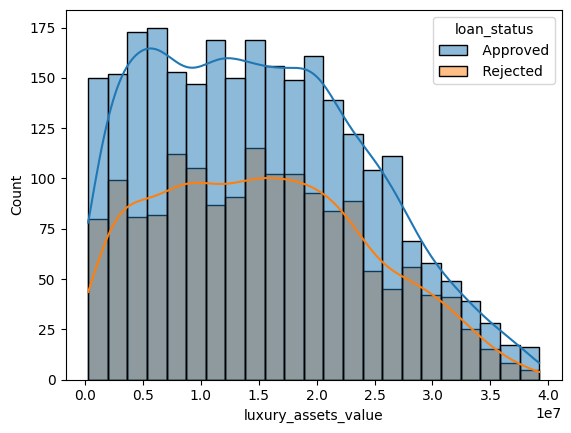

In [58]:
sns.histplot(x="luxury_assets_value", data=df,kde= True, hue="loan_status")
plt.show()

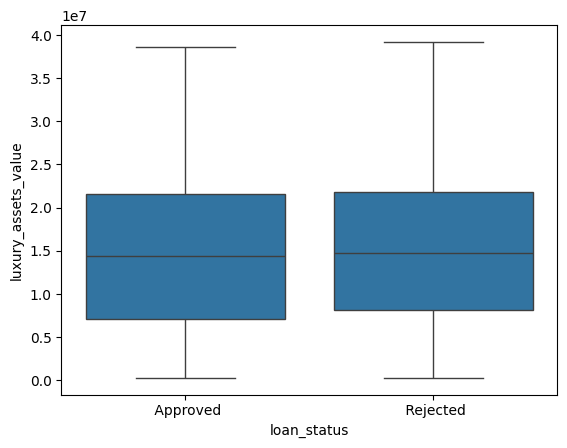

In [60]:
sns.boxplot(x='loan_status', y='luxury_assets_value', data=df)
plt.show()

### Insight

- luxury_assets_value is not strong differentiating feature for loan approval

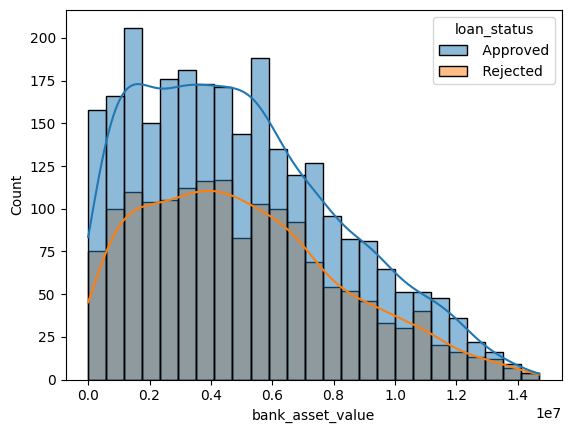

In [61]:
sns.histplot(x="bank_asset_value", data=df,kde= True, hue="loan_status")
plt.show()

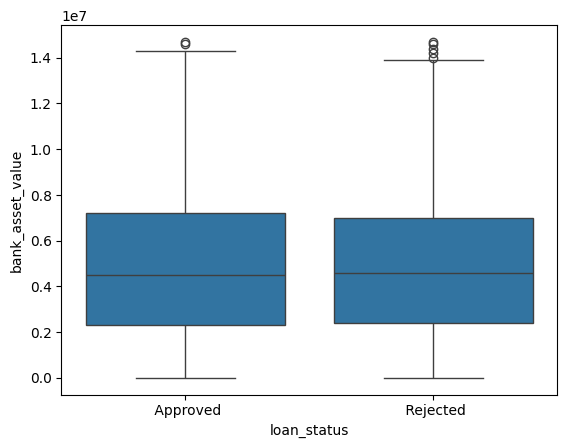

In [62]:
sns.boxplot(x='loan_status', y='bank_asset_value', data=df)
plt.show()

### Insight

- bank_asset_value is not strong differentiating feature for loan approval

#### Maximum values of numerical values 

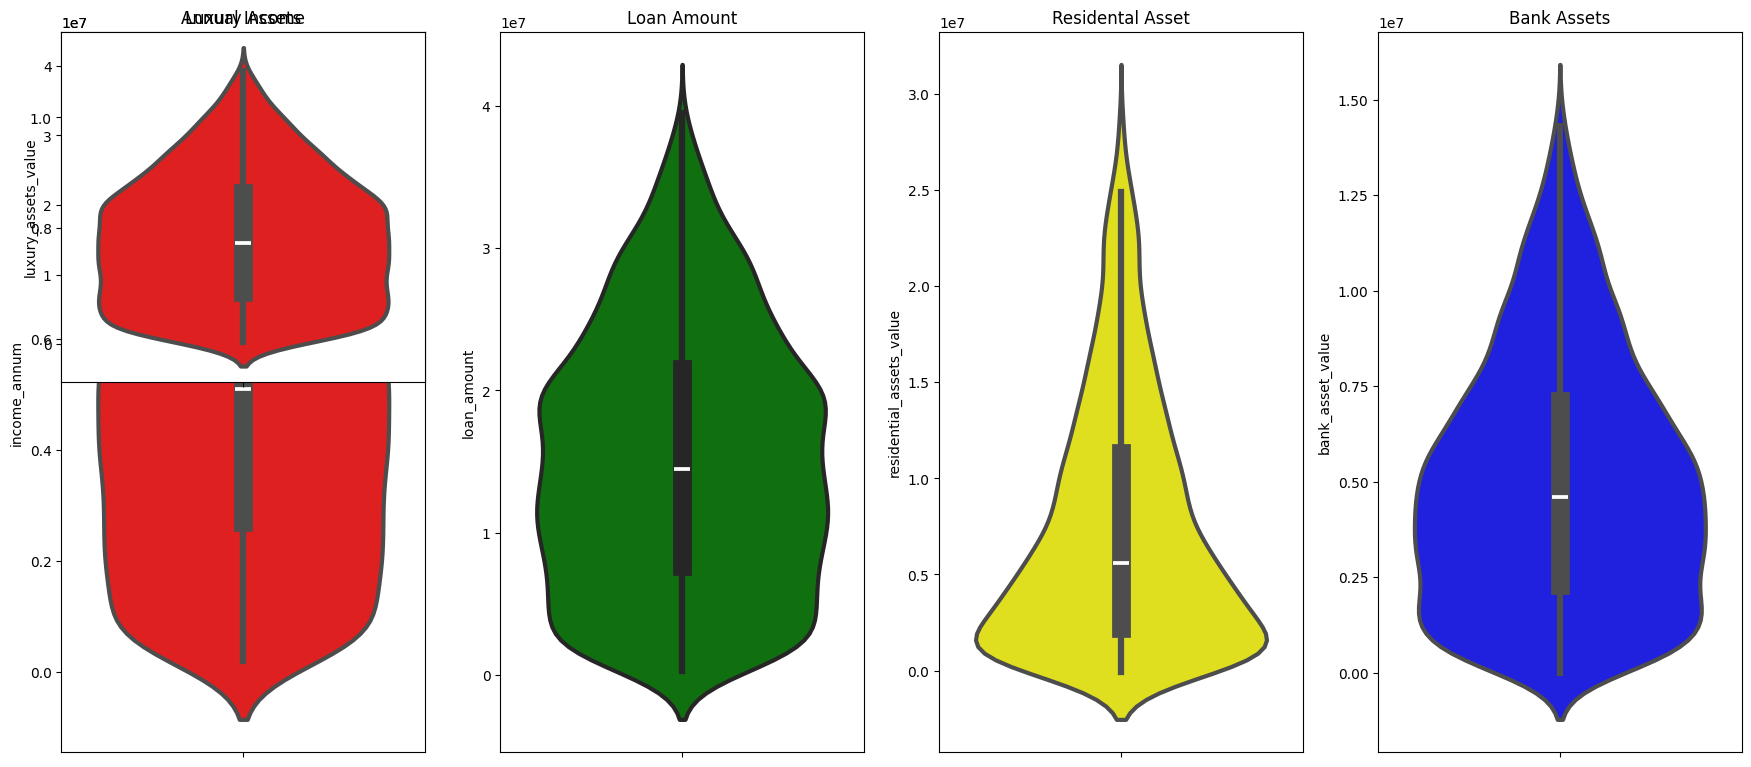

In [66]:
plt.figure(figsize=(18,8))

plt.subplot(1,4,1)
plt.title("Annual Income")
sns.violinplot(y='income_annum', data=df, color='red',linewidth=3)

plt.subplot(1,4,2)
plt.title("Loan Amount")
sns.violinplot(y='loan_amount', data=df, color='green',linewidth=3)

plt.subplot(1,4,3)
plt.title("Residental Asset")
sns.violinplot(y='residential_assets_value', data=df, color='yellow',linewidth=3)

plt.subplot(1,4,4)
plt.title("Bank Assets")
sns.violinplot(y='bank_asset_value', data=df, color='blue',linewidth=3)

plt.subplot(2,4,1)
plt.title("Luxury Assets")
sns.violinplot(y='luxury_assets_value', data=df, color='red',linewidth=3)

plt.tight_layout()
plt.show()


#### Multivariate analysis using pieplot

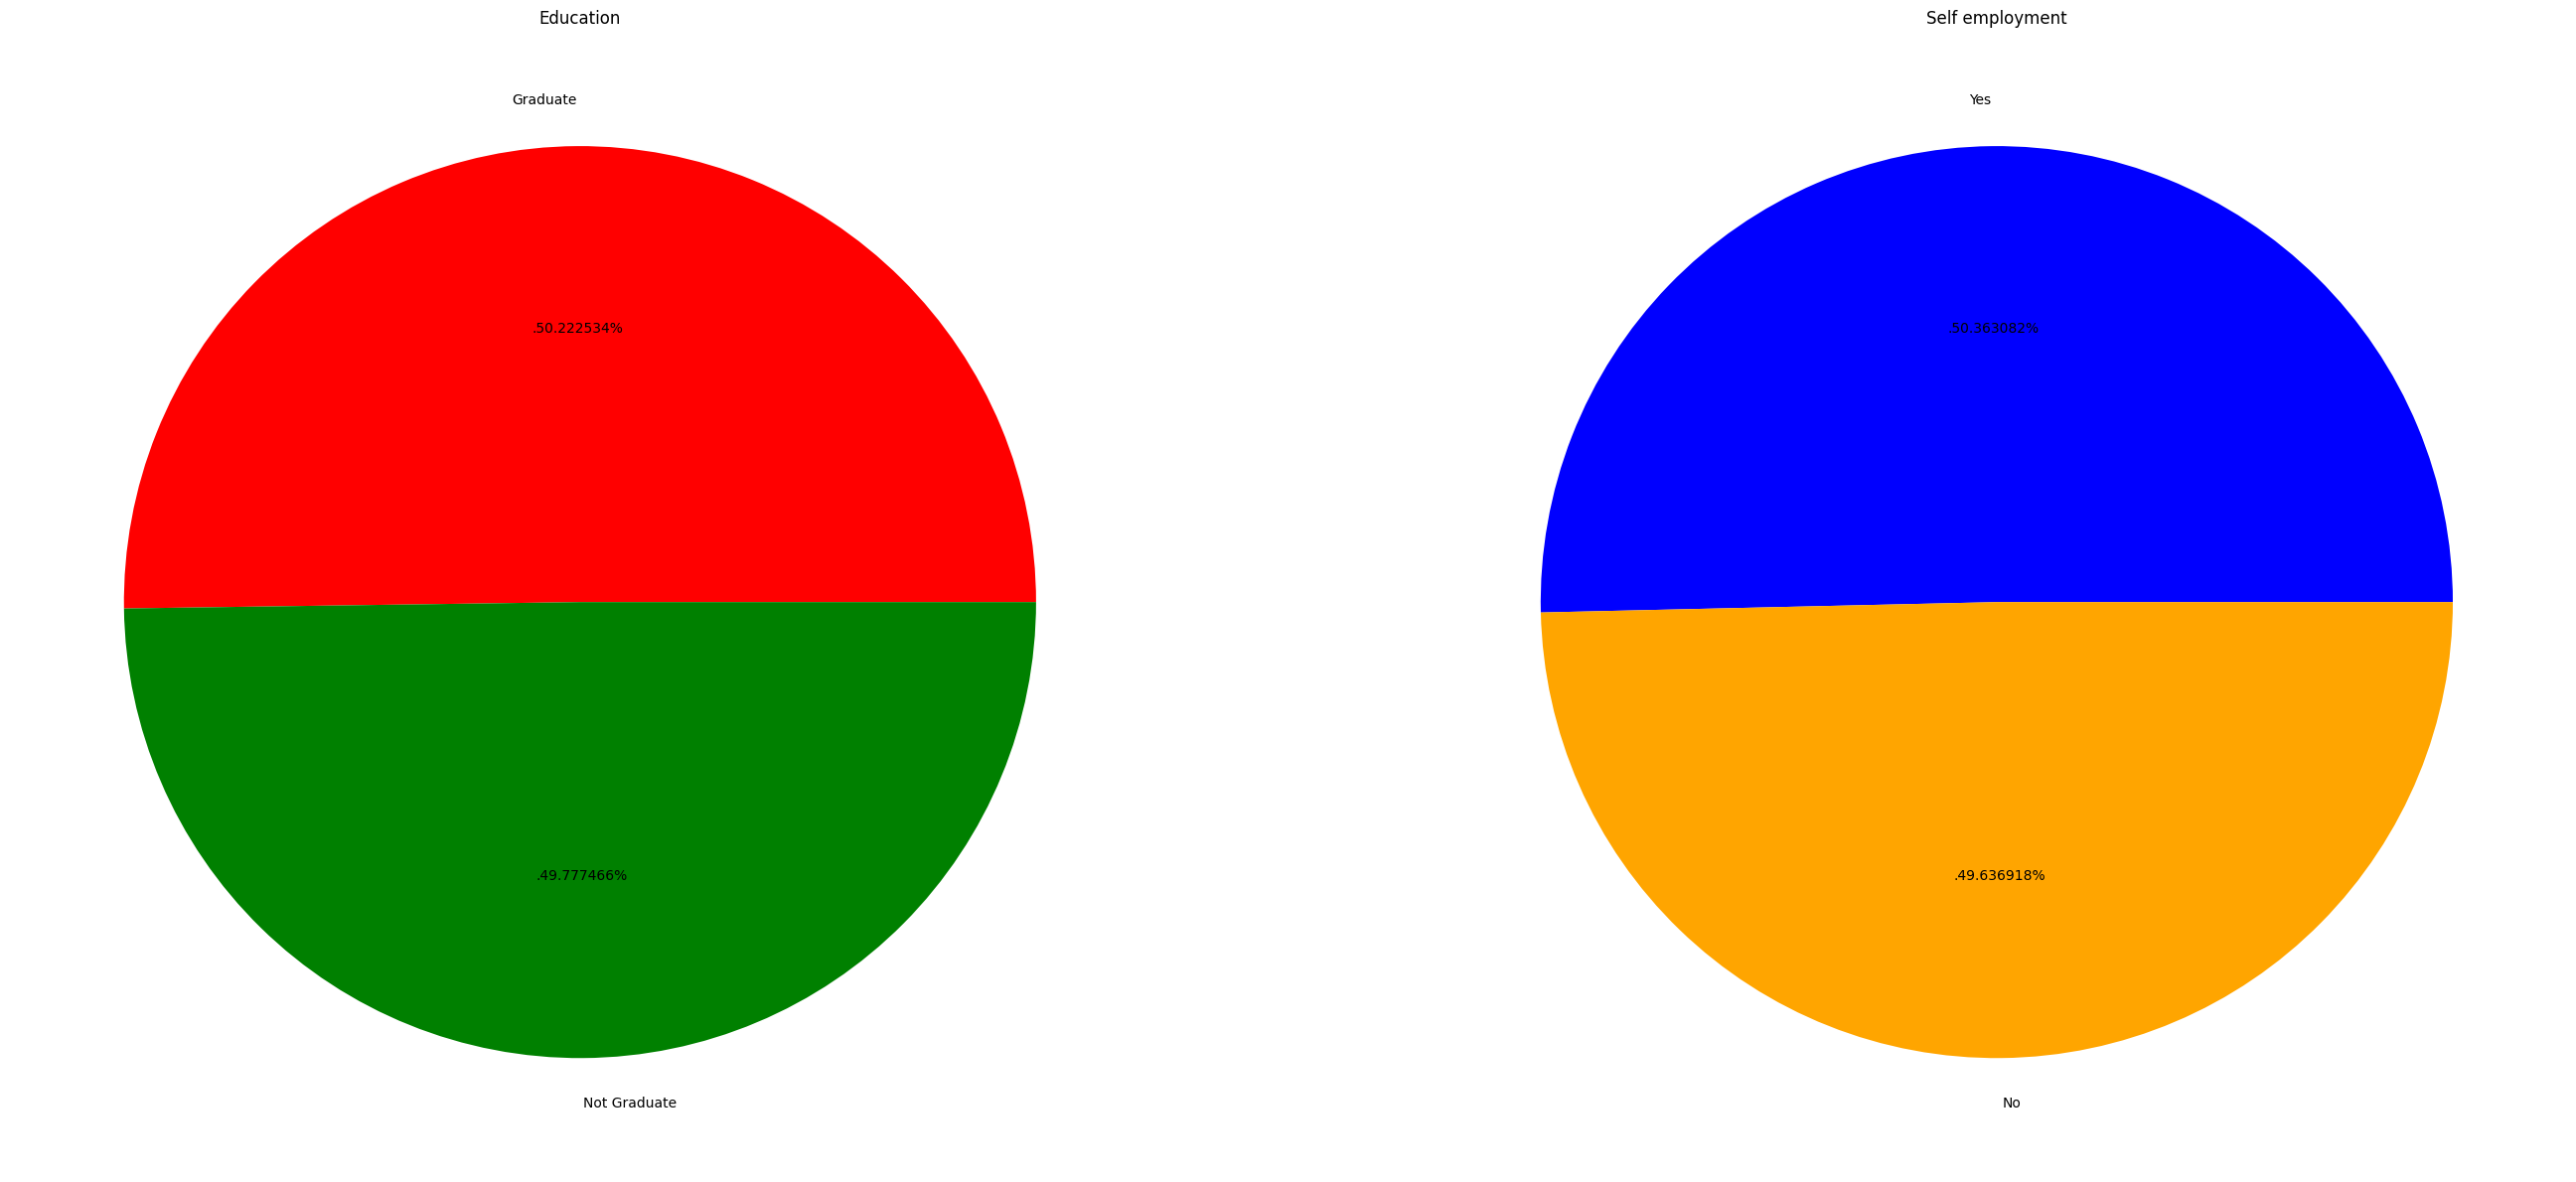

In [68]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1, 2, 1)
size = df['education'].value_counts()
labels = 'Graduate','Not Graduate'
color = ['red','green']

plt.pie(size, labels=labels, colors=color, autopct='.%2f%%')
plt.title("Education")
plt.axis('off')

plt.subplot(1, 2, 2)
size = df['self_employed'].value_counts()
labels = 'Yes','No'
color = ['blue', 'orange']

plt.pie(size, labels=labels, colors=color, autopct='.%2f%%')
plt.title("Self employment")
plt.axis("off")


plt.tight_layout()
plt.grid()

plt.show()


### Insight

- most of the people are graduated
- most of the people are also self employed

#### UNIVARIATE ANALYSIS 

In [70]:
df['education'].unique().tolist()

[' Graduate', ' Not Graduate']

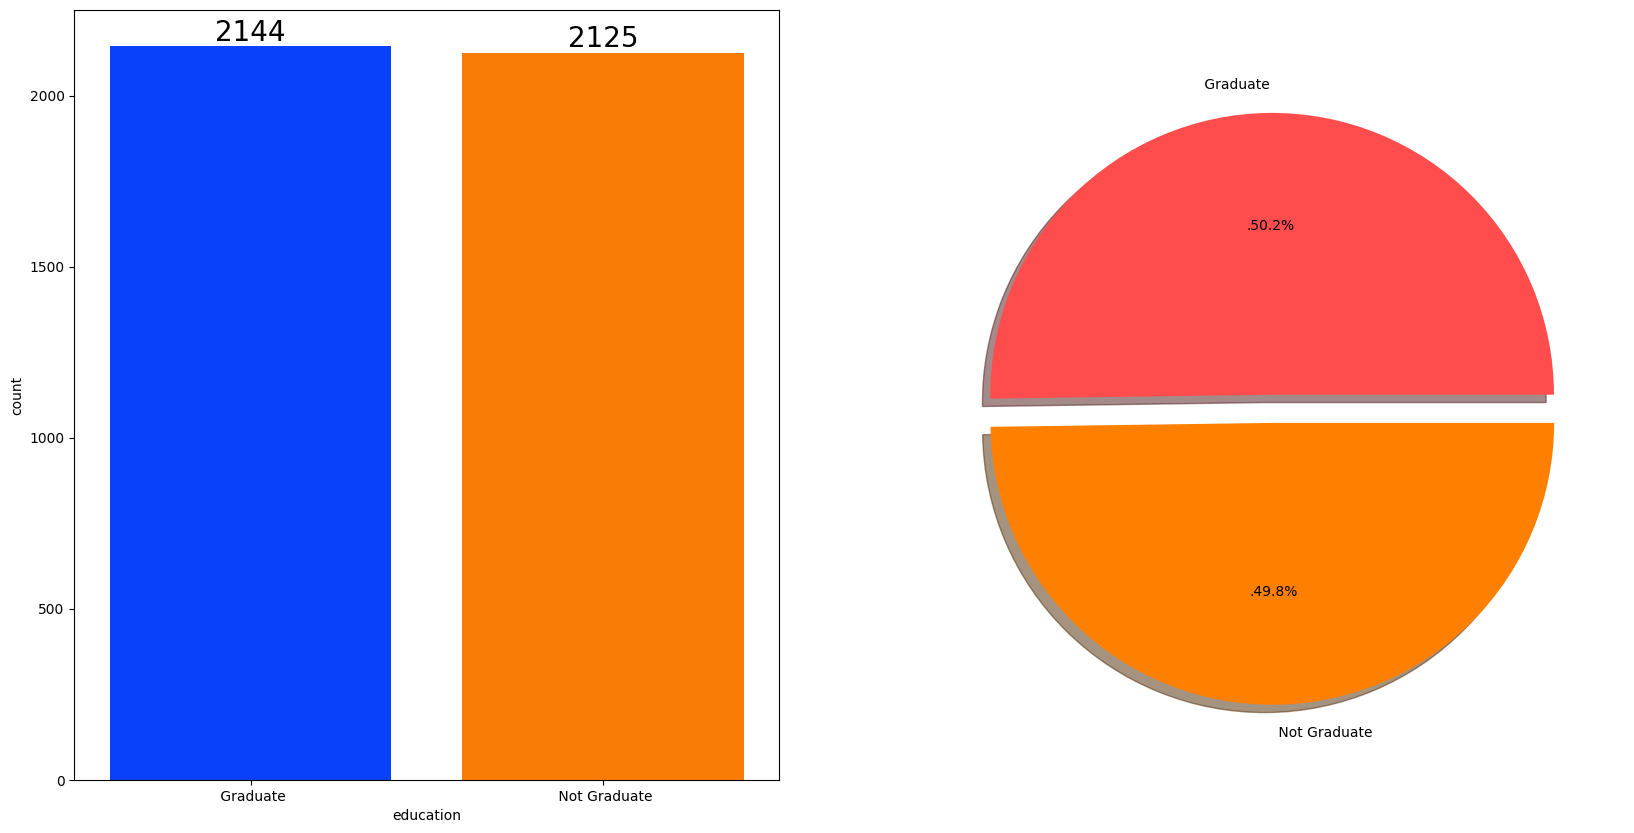

In [76]:
f, ax = plt.subplots(1, 2, figsize=(20,10))
sns.countplot(x=df['education'], data=df,hue=df['education'], palette='bright', ax=ax[0], saturation=0.95, legend=False)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

counts = df['education'].value_counts()

ax[1].pie(x=counts, labels=counts.index, explode=[0, 0.1], autopct='.%1.1f%%', shadow=True, colors=['#ff4d4d','#ff8000'])   
plt.show() 

### Insight 

- Graduation has balanced data 

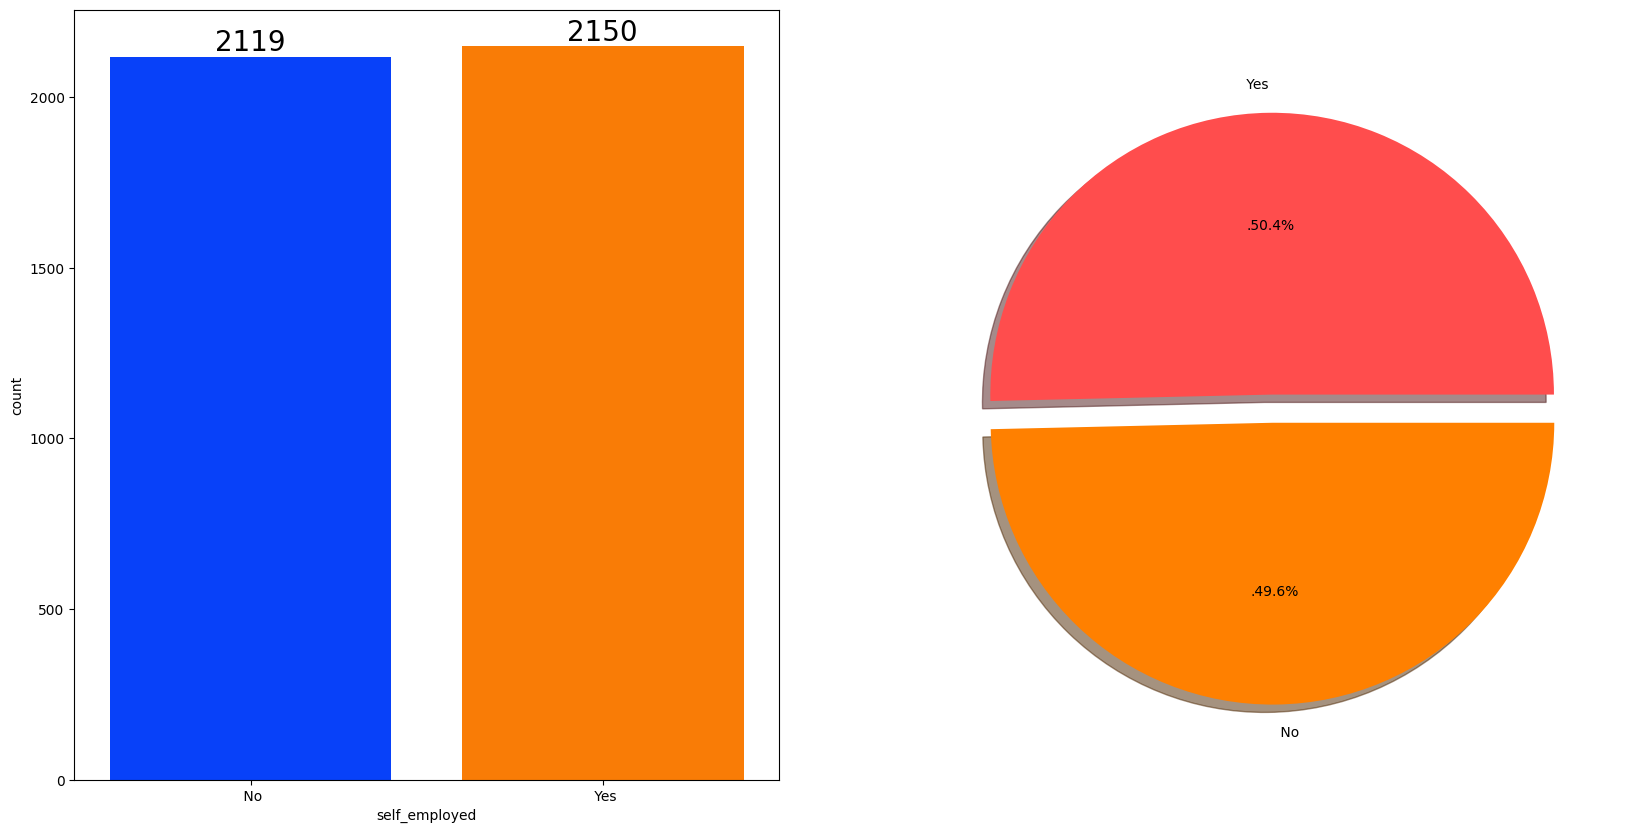

In [77]:
f, ax = plt.subplots(1, 2, figsize=(20,10))
sns.countplot(x=df['self_employed'], data=df,hue=df['self_employed'], palette='bright', ax=ax[0], saturation=0.95, legend=False)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

counts = df['self_employed'].value_counts()

ax[1].pie(x=counts, labels=counts.index, explode=[0, 0.1], autopct='.%1.1f%%', shadow=True, colors=['#ff4d4d','#ff8000'])   
plt.show() 

### Insight 

- Self employed has balanced data 

In [78]:
df['self_employed'].value_counts().index

Index([' Yes', ' No'], dtype='object', name='self_employed')

#### BIVARIATE ANALYSIS

In [79]:
graduate_group = df.groupby('education').mean(numeric_only=True)

In [80]:
graduate_group

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
education,,,,,,,,,
Graduate,2.503265,5.091604e+06,1.522915e+07,10.852612,599.138060,7.543377e+06,4.943610e+06,1.523932e+07,5.007183e+06
Not Graduate,2.494118,5.026353e+06,1.503689e+07,10.948706,600.741176,7.401224e+06,5.002965e+06,1.501228e+07,4.945929e+06


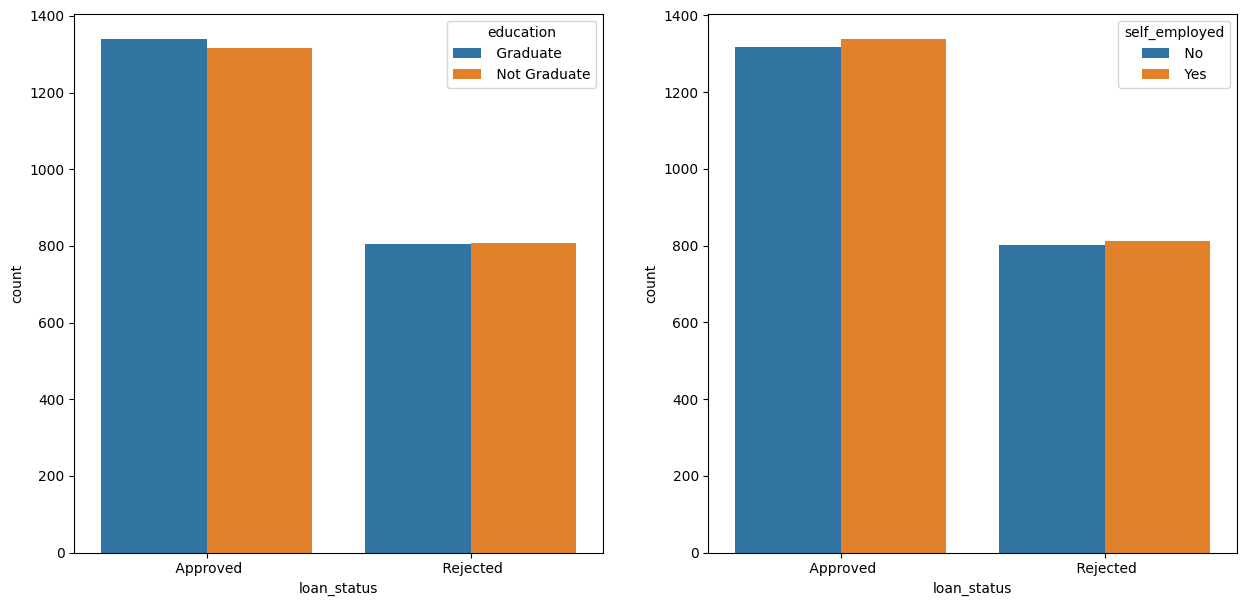

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.countplot(data=df, x="loan_status", hue="education")
plt.subplot(122)
sns.countplot(data=df, x="loan_status", hue="self_employed")
plt.show()

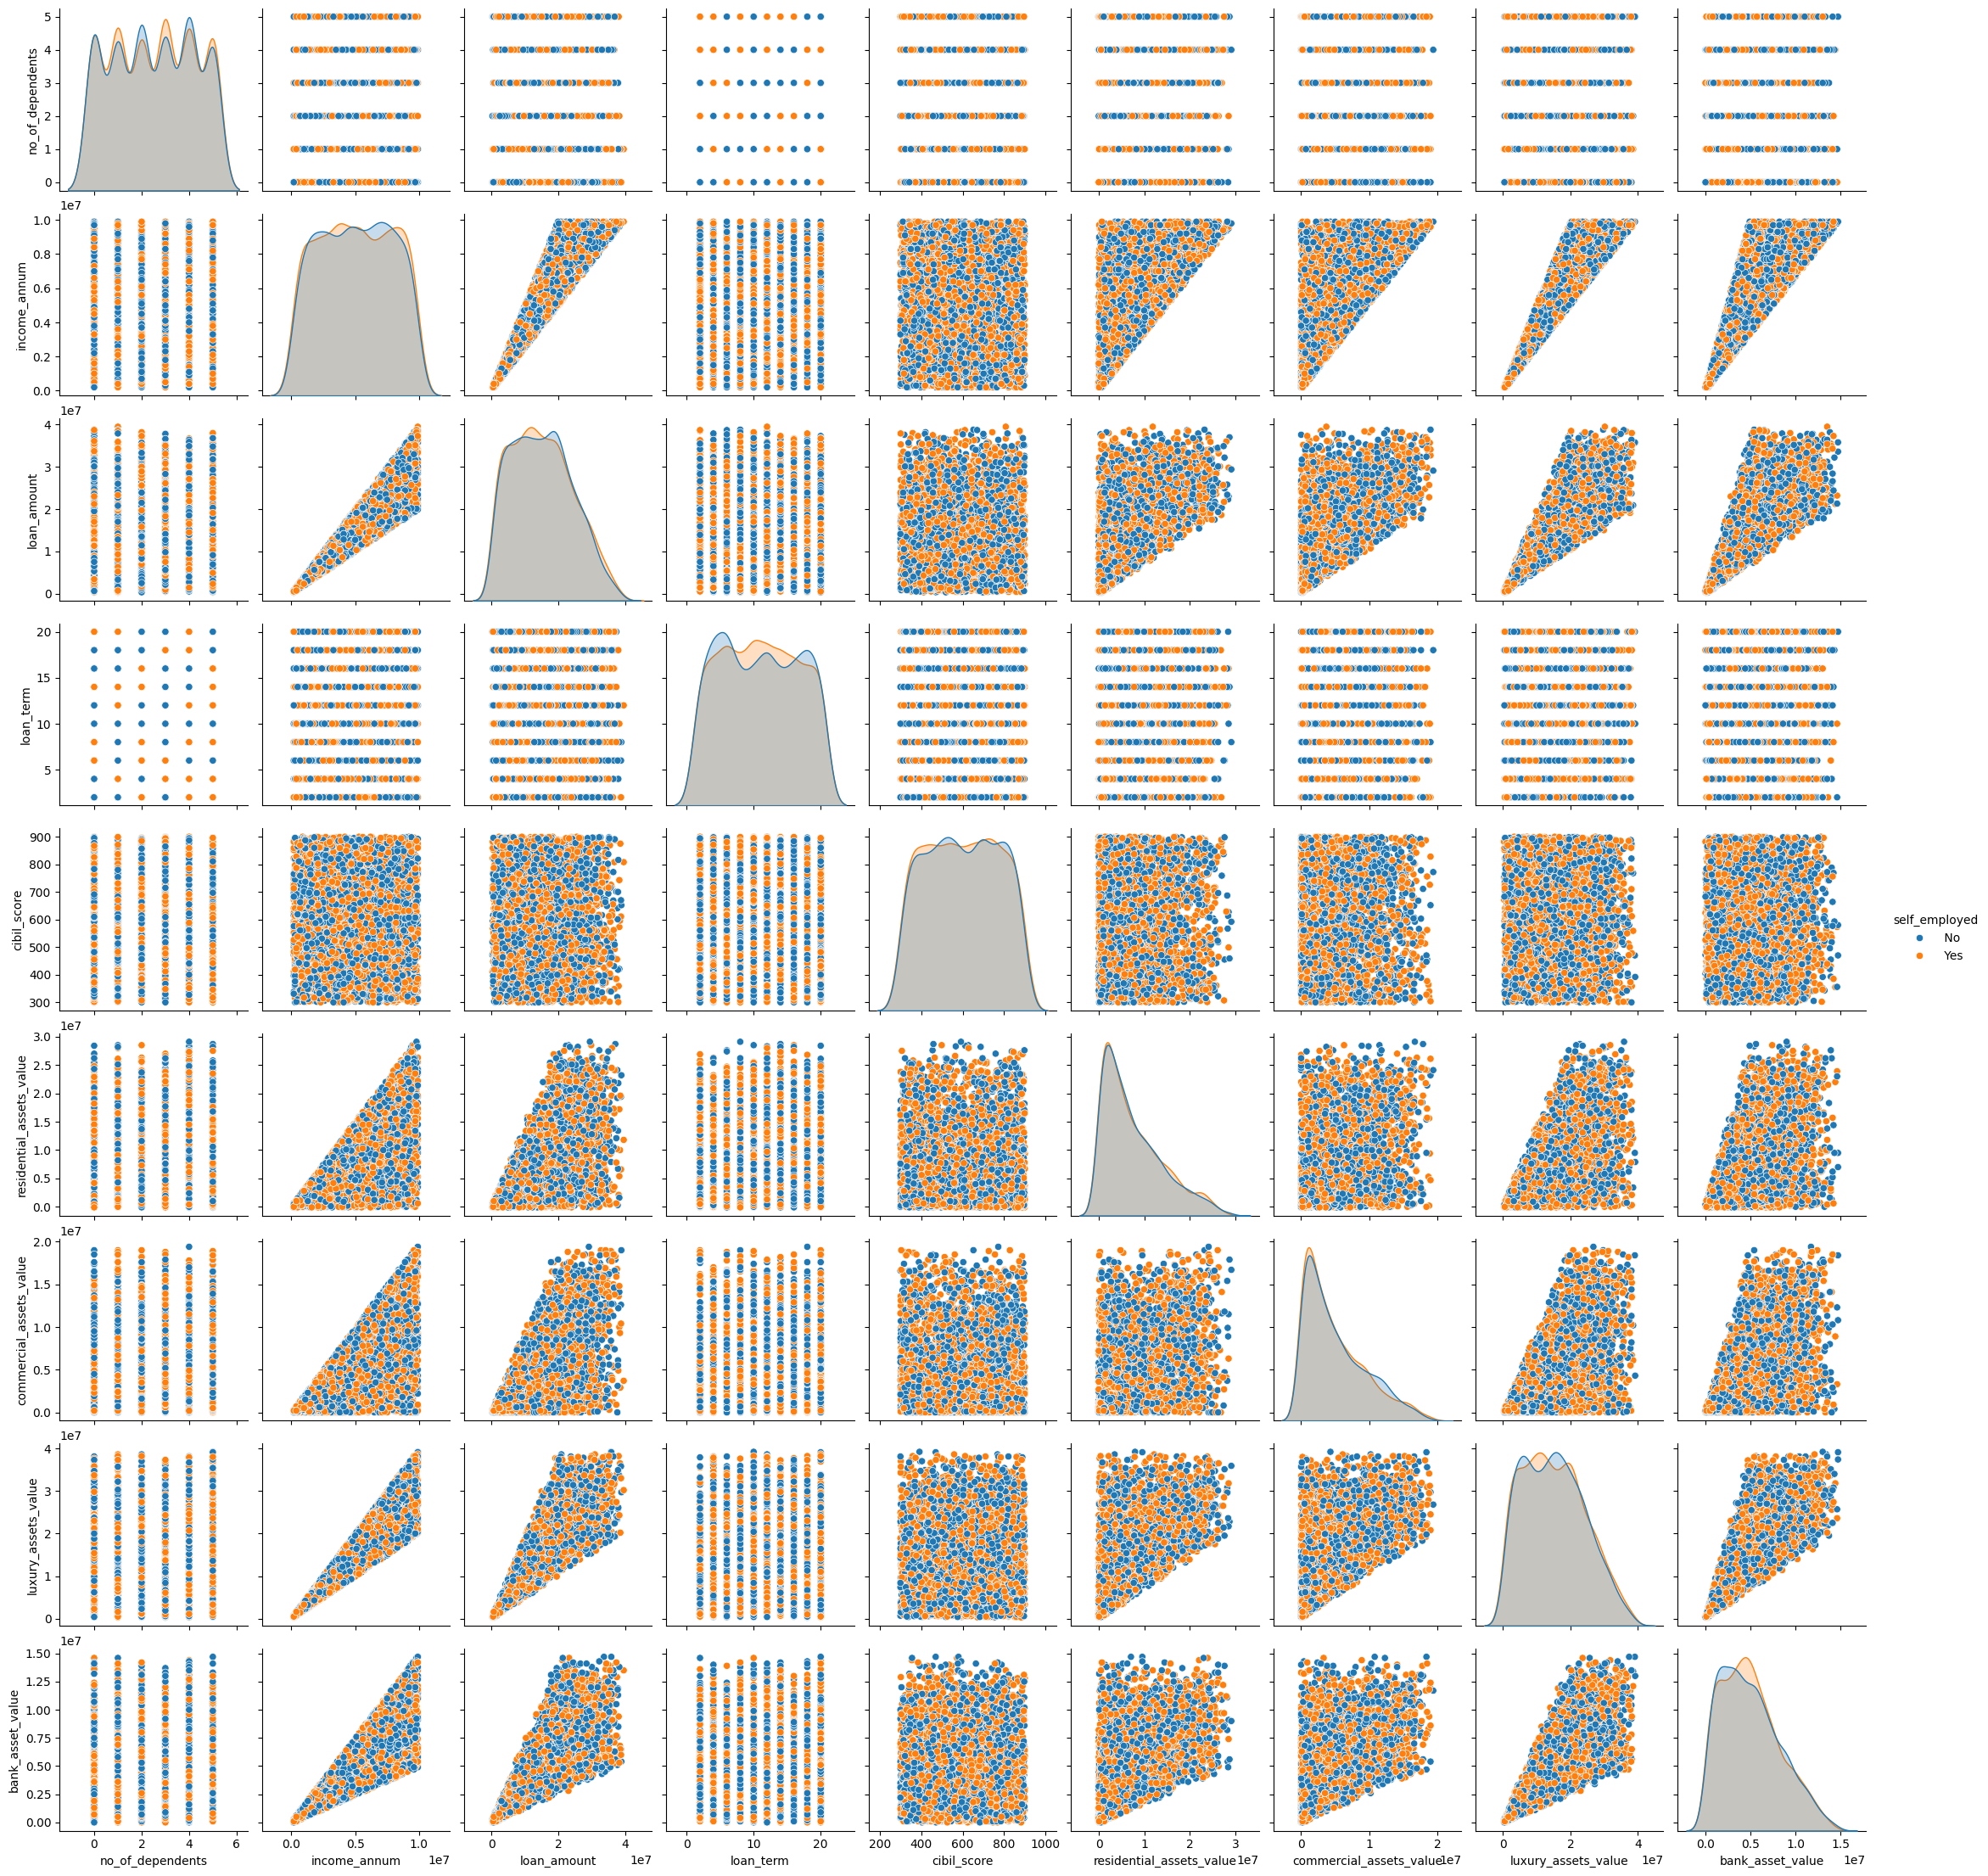

In [90]:
sns.pairplot(df,hue = 'self_employed')
plt.show()

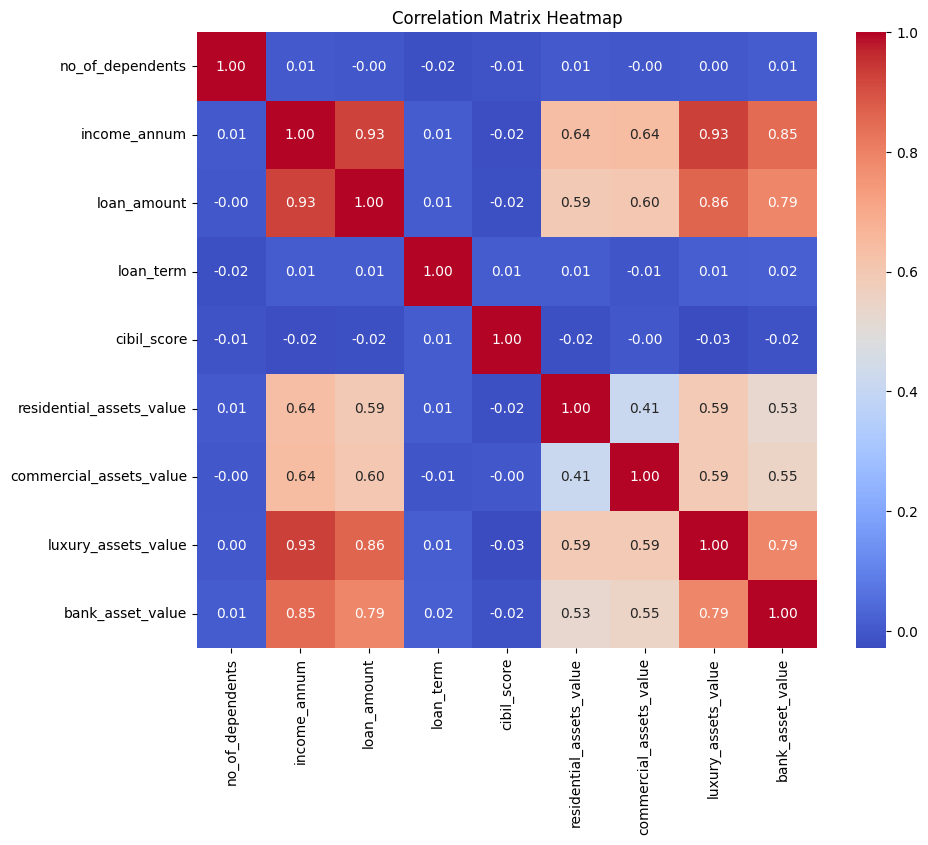

In [91]:
plt.figure(figsize=(10, 8))

# annot=True se numbers heatmap ke andar dikhte hain
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix Heatmap')
plt.show()